# Harmonized DOC Land Cover Exploration

Initial look with copilot:

This notebook explores the relationship between water quality measurements (DOC and DIC) and land cover characteristics (Trees and Wetlands) in the study area.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from land_cover.load import time_series_features_doc_parquet_pth

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load Parquet Data

In [4]:
df = pd.read_parquet(time_series_features_doc_parquet_pth.replace(".parquet", "_tsFeatures.parquet"))

print(f"Data loaded successfully. Shape: {df.shape}")

Data loaded successfully. Shape: (3808, 96)


## 3. Explore Data Structure

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3808 entries, 0 to 3807
Data columns (total 96 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   sample_idx                        3808 non-null   object 
 1   lat                               3808 non-null   float64
 2   lon                               3808 non-null   float64
 3   sample_id                         3808 non-null   object 
 4   area_km2                          1513 non-null   object 
 5   doc                               3568 non-null   float64
 6   dic                               1607 non-null   float64
 7   source                            3808 non-null   object 
 8   Outlet_id_tpcat                   3190 non-null   float64
 9   lake_id_tpcat                     3190 non-null   float64
 10  D_out_id_tpcat                    3190 non-null   float64
 11  D_lake_id_tpcat                   3190 non-null   float64
 12  Cat_ar

In [11]:
df["Trees_pct_2014"].describe()
# df["Trees_2014"].describe()

count    1571.000000
mean       38.067993
std        27.748463
min         0.000000
25%        10.669500
50%        37.168000
75%        60.101500
max       100.000000
Name: Trees_pct_2014, dtype: float64

## 4. Create Bar Plots for DOC by Trees_2014

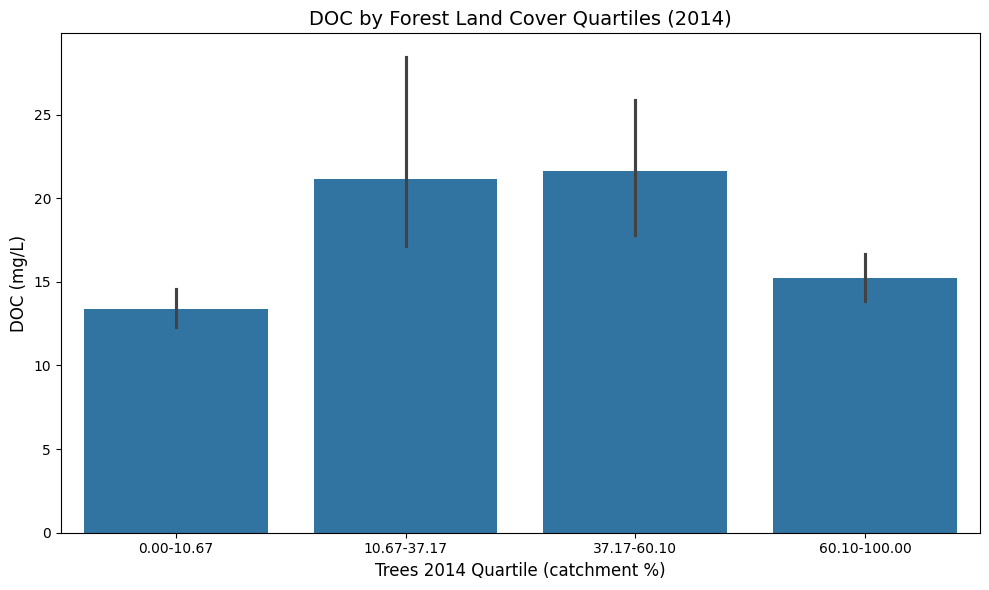

DOC by Trees_2014 Quartiles - Mean values:
Trees_2014_quartile
0.00-10.67      13.372614
10.67-37.17     21.164098
37.17-60.10     21.650409
60.10-100.00    15.215603
Name: doc, dtype: float64


/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_22661/1910373670.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"DOC by Trees_2014 Quartiles - Mean values:\n{df.groupby('Trees_2014_quartile')['doc'].mean()}")


In [ ]:
# Create quartile categories for Trees_pct_2014
trees_quartiles = np.quantile(df["Trees_pct_2014"].dropna(), [0, 0.25, 0.5, 0.75, 1.0])
trees_labels = [f"{trees_quartiles[i]:.2f}-{trees_quartiles[i+1]:.2f}" for i in range(len(trees_quartiles)-1)]
df["Trees_quartile"] = pd.qcut(df["Trees_pct_2014"], q=4, labels=trees_labels, duplicates="drop")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='Trees_quartile', y='doc', ax=ax)
ax.set_title('DOC by Trees Land Cover Quartiles (2014)', fontsize=14)
ax.set_xlabel('Trees 2014 Quartile (catchment %)', fontsize=12)
ax.set_ylabel('DOC (mg/L)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"DOC by Trees_pct_2014 Quartiles - Mean values:\n{df.groupby('Trees_quartile')['doc'].mean()}")

## 5. Create Bar Plots for DOC by Wetland_2014

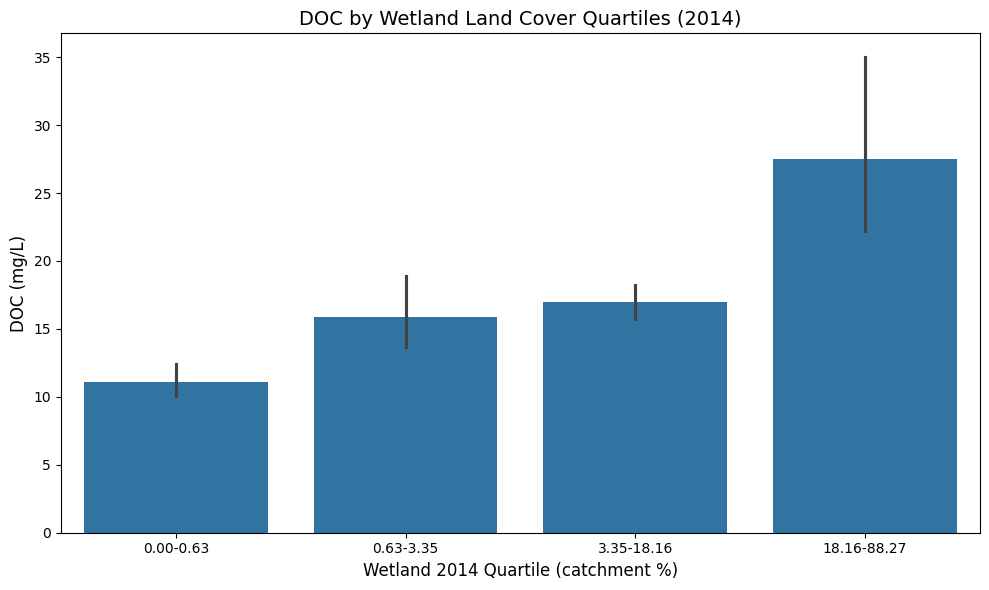

DOC by Wetland_pct_2014 Quartiles - Mean values:
Wetland_quartile
0.00-0.63      11.083953
0.63-3.35      15.896129
3.35-18.16     16.988678
18.16-88.27    27.535538
Name: doc, dtype: float64


/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_22661/4235409921.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"DOC by Wetland_pct_2014 Quartiles - Mean values:\n{df.groupby('Wetland_quartile')['doc'].mean()}")


In [15]:
# Create quartile categories for Wetland_pct_2014
wetland_quartiles = np.quantile(df["Wetland_pct_2014"].dropna(), [0, 0.25, 0.5, 0.75, 1.0])
wetland_labels = [f"{wetland_quartiles[i]:.2f}-{wetland_quartiles[i+1]:.2f}" for i in range(len(wetland_quartiles)-1)]
df["Wetland_quartile"] = pd.qcut(df["Wetland_pct_2014"], q=4, labels=wetland_labels, duplicates="drop")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='Wetland_quartile', y='doc', ax=ax)
ax.set_title('DOC by Wetland Land Cover Quartiles (2014)', fontsize=14)
ax.set_xlabel('Wetland 2014 Quartile (catchment %)', fontsize=12)
ax.set_ylabel('DOC (mg/L)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"DOC by Wetland_pct_2014 Quartiles - Mean values:\n{df.groupby('Wetland_quartile')['doc'].mean()}")

## 6. Create Scatter Plots for DOC by Trees_2014

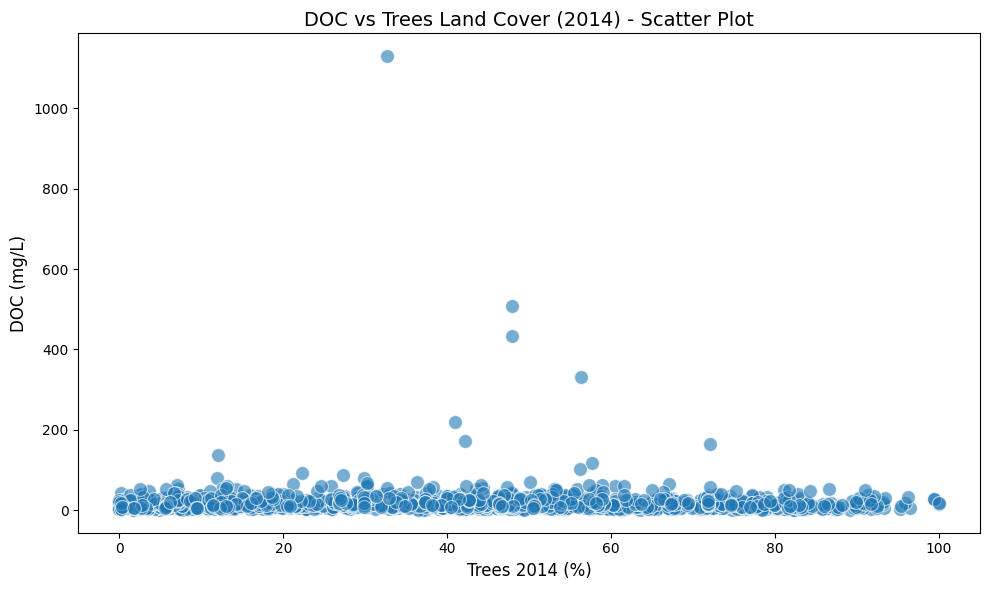

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Trees_pct_2014', y='doc', ax=ax, s=100, alpha=0.6)
ax.set_title('DOC vs Trees Land Cover (2014) - Scatter Plot', fontsize=14)
ax.set_xlabel('Trees 2014 (%)', fontsize=12)
ax.set_ylabel('DOC (mg/L)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Create Scatter Plots for DOC by Wetland_2014

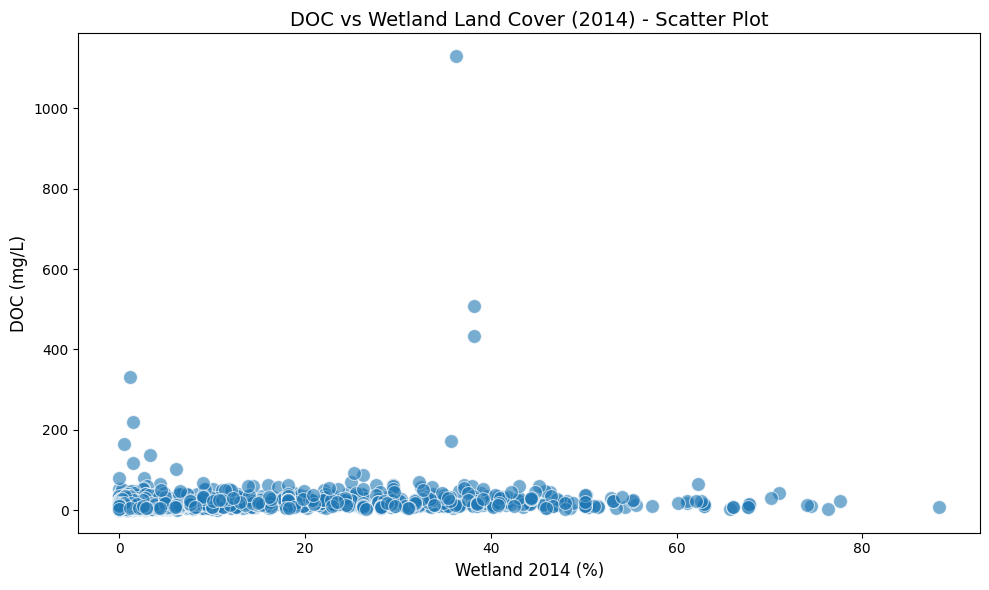

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Wetland_pct_2014', y='doc', ax=ax, s=100, alpha=0.6)
ax.set_title('DOC vs Wetland Land Cover (2014) - Scatter Plot', fontsize=14)
ax.set_xlabel('Wetland 2014 (%)', fontsize=12)
ax.set_ylabel('DOC (mg/L)', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Create Bar Plots for DIC by Trees_2014

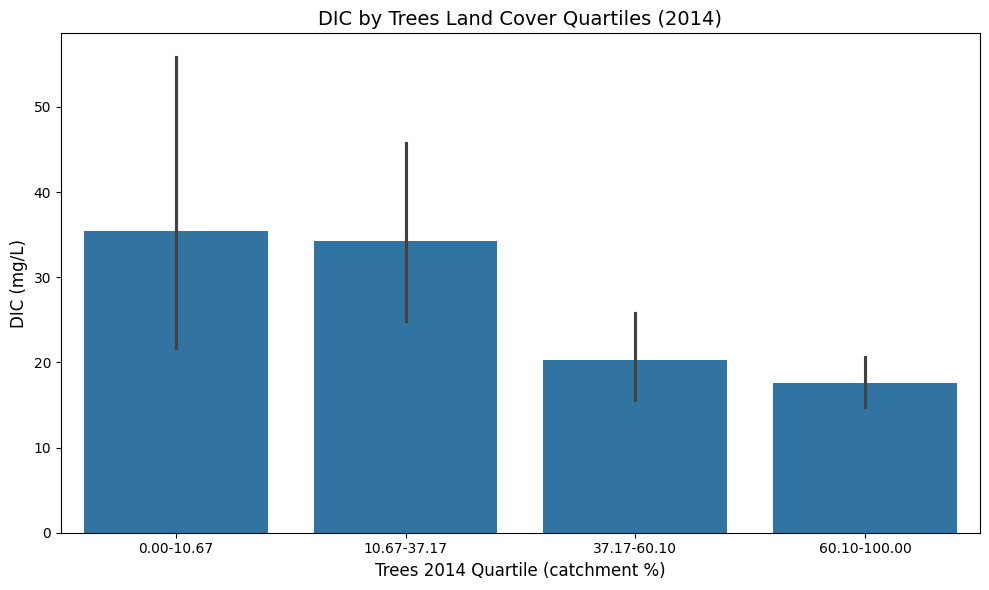

DIC by Trees_pct_2014 Quartiles - Mean values:
Forest_quartile
0.00-10.67      35.390132
10.67-37.17     34.244738
37.17-60.10     20.337937
60.10-100.00    17.549646
Name: dic, dtype: float64


/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_22661/2222848542.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  f"DIC by Trees_pct_2014 Quartiles - Mean values:\n{df.groupby('Forest_quartile')['dic'].mean()}"


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='Forest_quartile', y='dic', ax=ax)
ax.set_title('DIC by Trees Land Cover Quartiles (2014)', fontsize=14)
ax.set_xlabel('Trees 2014 Quartile (catchment %)', fontsize=12)
ax.set_ylabel('DIC (mg/L)', fontsize=12)
plt.tight_layout()
plt.show()

print(
    f"DIC by Trees_pct_2014 Quartiles - Mean values:\n{df.groupby('Forest_quartile')['dic'].mean()}"
)

## 9. Create Bar Plots for DIC by Wetland_2014

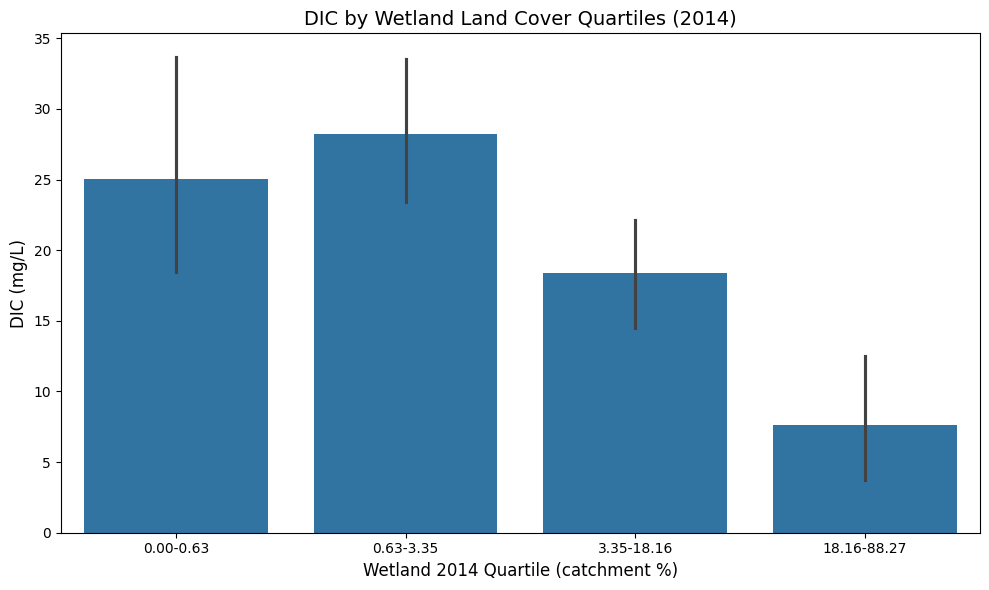

DIC by Wetland_pct_2014 Quartiles - Mean values:
Wetland_quartile
0.00-0.63      25.074100
0.63-3.35      28.224712
3.35-18.16     18.407865
18.16-88.27     7.596071
Name: dic, dtype: float64


/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_22661/1918792432.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"DIC by Wetland_pct_2014 Quartiles - Mean values:\n{df.groupby('Wetland_quartile')['dic'].mean()}")


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='Wetland_quartile', y='dic', ax=ax)
ax.set_title('DIC by Wetland Land Cover Quartiles (2014)', fontsize=14)
ax.set_xlabel('Wetland 2014 Quartile (catchment %)', fontsize=12)
ax.set_ylabel('DIC (mg/L)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"DIC by Wetland_pct_2014 Quartiles - Mean values:\n{df.groupby('Wetland_quartile')['dic'].mean()}")

## 10. Create Scatter Plots for DIC by Trees_2014

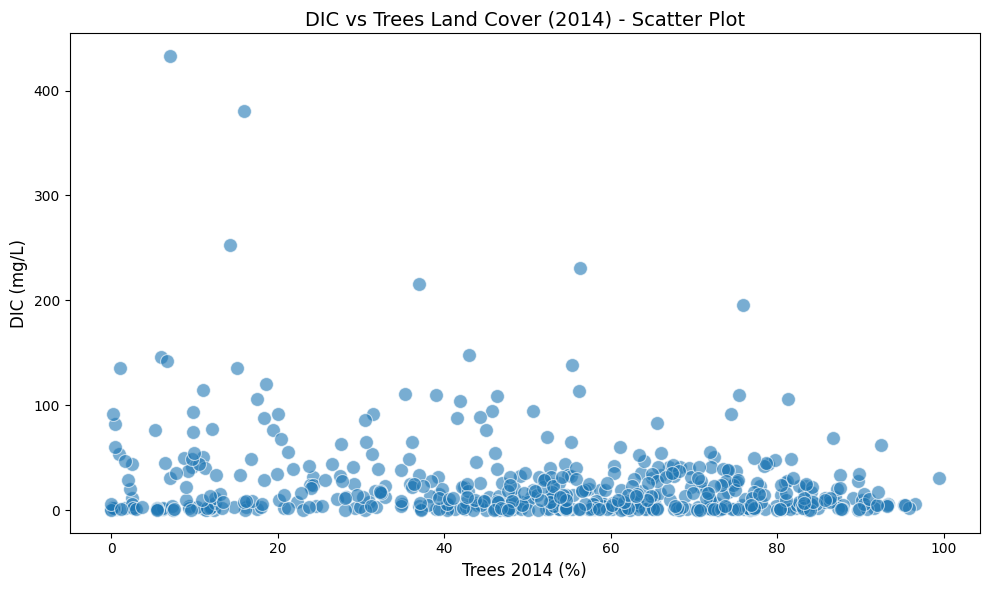

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Trees_pct_2014', y='dic', ax=ax, s=100, alpha=0.6)
ax.set_title('DIC vs Trees Land Cover (2014) - Scatter Plot', fontsize=14)
ax.set_xlabel('Trees 2014 (%)', fontsize=12)
ax.set_ylabel('DIC (mg/L)', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Create Scatter Plots for DIC by Wetland_2014

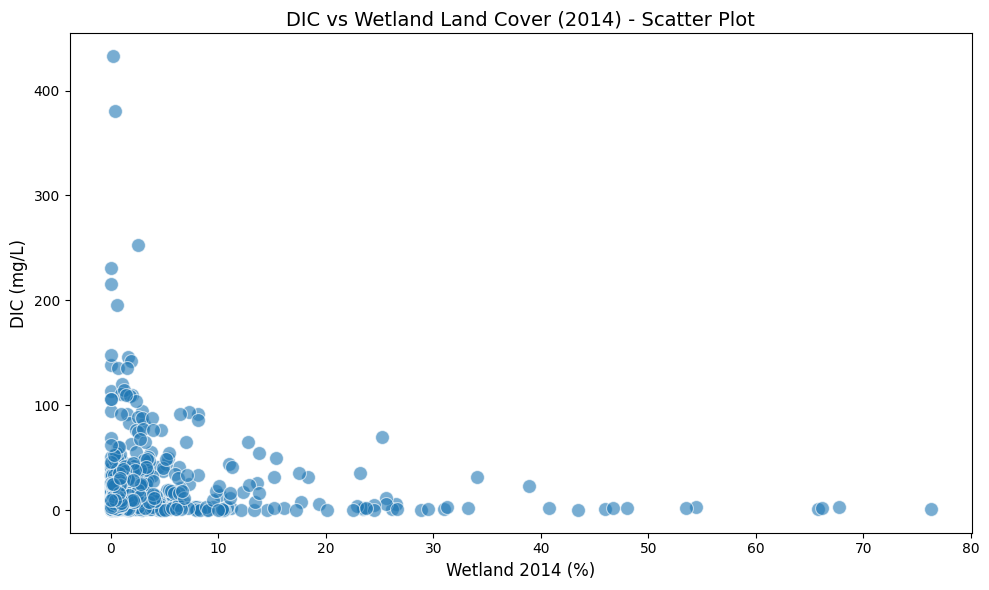

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Wetland_pct_2014', y='dic', ax=ax, s=100, alpha=0.6)
ax.set_title('DIC vs Wetland Land Cover (2014) - Scatter Plot', fontsize=14)
ax.set_xlabel('Wetland 2014 (%)', fontsize=12)
ax.set_ylabel('DIC (mg/L)', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Create Bar Plots for DOC:DIC Ratio by Trees_2014

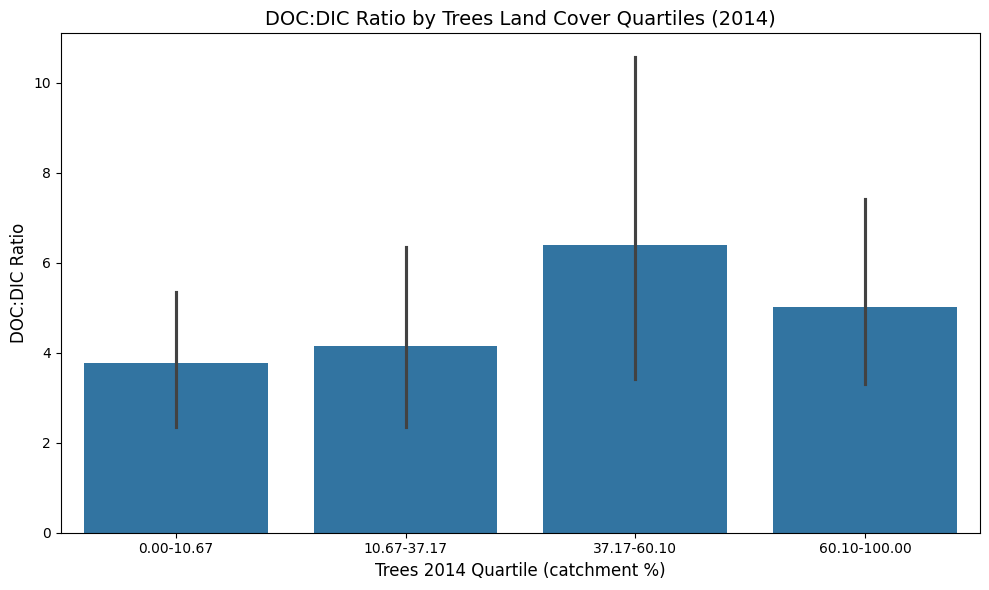

DOC:DIC Ratio by Trees_pct_2014 Quartiles - Mean values:
Forest_quartile
0.00-10.67      3.759079
10.67-37.17     4.150141
37.17-60.10     6.394227
60.10-100.00    5.019076
Name: doc_dic_ratio, dtype: float64


/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_22661/3535655240.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"DOC:DIC Ratio by Trees_pct_2014 Quartiles - Mean values:\n{df.groupby('Forest_quartile')['doc_dic_ratio'].mean()}")


In [25]:
# Calculate DOC:DIC ratio
df['doc_dic_ratio'] = df['doc'] / df['dic']

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='Forest_quartile', y='doc_dic_ratio', ax=ax)
ax.set_title('DOC:DIC Ratio by Trees Land Cover Quartiles (2014)', fontsize=14)
ax.set_xlabel('Trees 2014 Quartile (catchment %)', fontsize=12)
ax.set_ylabel('DOC:DIC Ratio', fontsize=12)
plt.tight_layout()
plt.show()

print(f"DOC:DIC Ratio by Trees_pct_2014 Quartiles - Mean values:\n{df.groupby('Forest_quartile')['doc_dic_ratio'].mean()}")

## 13. Create Bar Plots for DOC:DIC Ratio by Wetland_2014

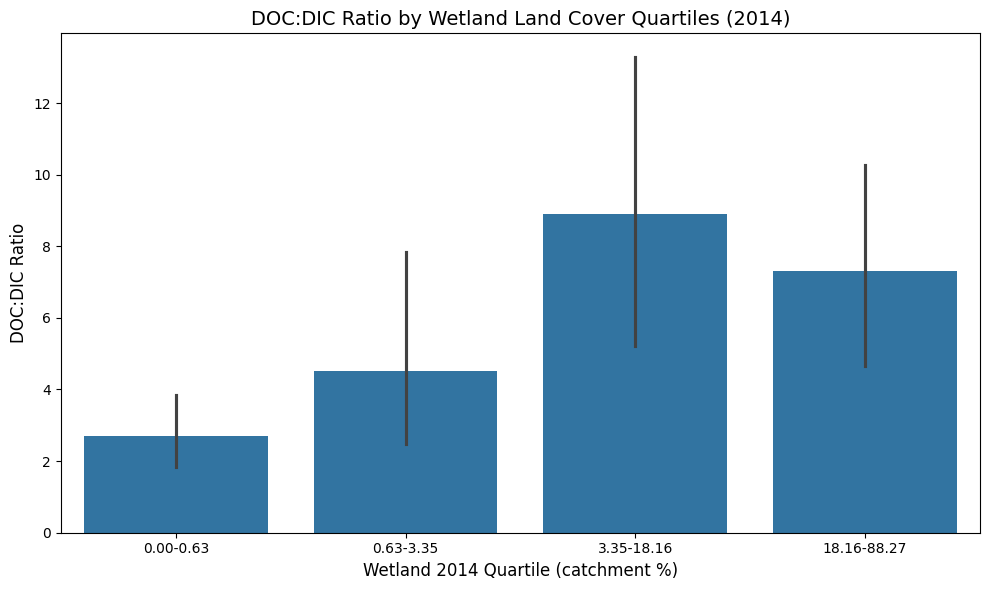

DOC:DIC Ratio by Wetland_pct_2014 Quartiles - Mean values:
Wetland_quartile
0.00-0.63      2.696332
0.63-3.35      4.507136
3.35-18.16     8.901063
18.16-88.27    7.303064
Name: doc_dic_ratio, dtype: float64


/var/folders/rv/sn0kln2103b9fs4xl56n3w7w0000gn/T/ipykernel_22661/1783019462.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"DOC:DIC Ratio by Wetland_pct_2014 Quartiles - Mean values:\n{df.groupby('Wetland_quartile')['doc_dic_ratio'].mean()}")


In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df, x='Wetland_quartile', y='doc_dic_ratio', ax=ax)
ax.set_title('DOC:DIC Ratio by Wetland Land Cover Quartiles (2014)', fontsize=14)
ax.set_xlabel('Wetland 2014 Quartile (catchment %)', fontsize=12)
ax.set_ylabel('DOC:DIC Ratio', fontsize=12)
plt.tight_layout()
plt.show()

print(f"DOC:DIC Ratio by Wetland_pct_2014 Quartiles - Mean values:\n{df.groupby('Wetland_quartile')['doc_dic_ratio'].mean()}")